In [1]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score
)

from sklearn.inspection import permutation_importance


In [2]:
def extract_participant_features(participant_id, base_path):
    """
    Extracts and normalizes features across multiple participants.
    """
    try:
        """
        Load Baseline (0-Back) and Overload (2-Back) ET files
        Dataset naming convention:
        Folder = ID10
        File   = ID010_ET_0.xlsx
        """
        participant_number = int(participant_id[2:])

        file_id = (
            f"ID0{participant_number}"
            if participant_number >= 10
            else participant_id
        )

        f_norm = f"{base_path}\\{participant_id}\\Dual\\ET\\{file_id}_ET_0.xlsx"
        f_over = f"{base_path}\\{participant_id}\\Dual\\ET\\{file_id}_ET_2.xlsx"

        df_norm = pd.read_excel(f_norm)
        df_over = pd.read_excel(f_over)
        
        # Filter valid rows
        df_norm = df_norm[(df_norm['LPV'] == 1) & (df_norm['RPV'] == 1)].copy()
        df_over = df_over[(df_over['LPV'] == 1) & (df_over['RPV'] == 1)].copy()
        
        # Calculate baseline mean pupil diameter for normalization
        baseline_pupil_mean = (df_norm['LPD'].mean() + df_norm['RPD'].mean()) / 2.0
        
        def build_df(df, label):
            """
            FEATURE EXTRACTION FUNCTION
            Build a DataFrame with features and labels for a given participant.
            returns a DataFrame with columns: 
            participant, pupil_delta, blink_duration, blink_rate, risk_label
            """
            pupil_avg = (df['LPD'] + df['RPD']) / 2.0
            return pd.DataFrame({
                "participant": participant_id, # Participant ID
                'pupil_delta': pupil_avg - baseline_pupil_mean, # Deviation from baseline
                'blink_duration': df['BKDUR'],                 # Blink Duration
                'blink_rate': df['BKPMIN'],                   # Blink Rate per minute
                'risk_label': label
            })
        # Build DataFrames for both conditions (0-Back and 2-Back)            
        df_0 = build_df(df_norm, label=0)
        df_2 = build_df(df_over, label=2)
        
        return pd.concat([df_0, df_2], ignore_index=True).dropna()

    except Exception as e:
        print(f"Skipping {participant_id}: {e}")
        return None

# Get base directory path

base_dir = Path("Data").resolve()


"""
FEATURE EXTRACTION AND NORMALIZATION
Loads from ID1 to ID028, extracts features, and normalizes them across participants.
Loads and normalizes features across multiple participants, combining them into a single dataset.
"""
participant_list = [f"ID{i:02d}" for i in range(1,29)]

"""
Concatenate all participant data into a single DataFrame. 
Filtering out any None values returned from the extraction function.
"""
print ("\nExtracting and normalizing features for participants...")
print(f"Base directory: {base_dir}")
all_data = [extract_participant_features(p, base_dir) for p in participant_list]
if all_data is None or all(d is None for d in all_data):
    raise ValueError("No valid participant data found. Please check the data files.")
else:
    print(f"Successfully extracted features for {len([d for d in all_data if d is not None])} participants.")

combined_dataset = pd.concat([d for d in all_data if d is not None], ignore_index=True)

print("\nParticipants successfully loaded:")
print(combined_dataset["participant"].unique())
print("Total participants:", len(combined_dataset["participant"].unique()))


Extracting and normalizing features for participants...
Base directory: C:\Dissertation\SUBMISSION\Artefact\Data
Successfully extracted features for 28 participants.

Participants successfully loaded:
<StringArray>
['ID01', 'ID02', 'ID03', 'ID04', 'ID05', 'ID06', 'ID07', 'ID08', 'ID09',
 'ID10', 'ID11', 'ID12', 'ID13', 'ID14', 'ID15', 'ID16', 'ID17', 'ID18',
 'ID19', 'ID20', 'ID21', 'ID22', 'ID23', 'ID24', 'ID25', 'ID26', 'ID27',
 'ID28']
Length: 28, dtype: str
Total participants: 28


In [3]:
# Train ML Model
X = combined_dataset[['pupil_delta', 'blink_duration', 'blink_rate']]
y = combined_dataset['risk_label']

In [4]:
"""
Participant-Level Train/Test Split
trains on 20 participants and tests on the remaining participants, ensuring no data leakage.
Also 
"""
participants = combined_dataset["participant"].unique()

np.random.seed(42)

train_participants = np.random.choice(
    participants,
    size=20,
    replace=False
)

test_participants = np.setdiff1d(
    participants,
    train_participants
)

print("\nTraining participants:")
print(sorted(train_participants))

print("\nTesting participants:")
print(sorted(test_participants))

train_df = combined_dataset[
    combined_dataset["participant"].isin(train_participants)
]

test_df = combined_dataset[
    combined_dataset["participant"].isin(test_participants)
]

X_train = train_df[
    ["pupil_delta",
     "blink_duration",
     "blink_rate"]
]

y_train = train_df["risk_label"]

X_test = test_df[
    ["pupil_delta",
     "blink_duration",
     "blink_rate"]
]

y_test = test_df["risk_label"]

print(f"\nTraining samples: {len(train_df)}")
print(f"Testing samples : {len(test_df)}")


Training participants:
['ID01', 'ID02', 'ID03', 'ID04', 'ID05', 'ID06', 'ID09', 'ID10', 'ID12', 'ID13', 'ID14', 'ID16', 'ID17', 'ID18', 'ID22', 'ID23', 'ID24', 'ID25', 'ID26', 'ID27']

Testing participants:
['ID07', 'ID08', 'ID11', 'ID15', 'ID19', 'ID20', 'ID21', 'ID28']

Training samples: 387957
Testing samples : 148214


In [5]:
"""
train the Random Forest Classifier with specified hyperparameters, fit it to the training data, and evaluate its performance on the test set.
Parameters chosen for:
- n_estimators=300: A moderate number of trees to balance performance and training time.
- max_depth=12: To prevent overfitting while allowing the model to capture complex patterns.
- min_samples_leaf=5: Ensures that leaf nodes have a minimum number of samples, reducing overfitting.
- min_samples_split=10: A node must have at least 10 samples to be split, which helps prevent overfitting on small datasets.
- class_weight="balanced": Adjusts weights inversely proportional to class frequencies, useful for imbalanced datasets.
- random_state=42: 42 seed, ensuring reproducibility of results across different runs.
- n_jobs=-1: Utilizes all available CPU cores for parallel processing, speeding up training.
"""
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
# Fit the model to the training data
clf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fea

In [6]:

""" 
Model Evaluation
Evaluates the trained model on the test set.
Calculates participant-level accuracy and overall classification metrics.
accuracy_score: Computes the accuracy of the model's predictions using the formula: 
```(number of correct predictions) / (total number of predictions).```
Utilizes sklearn's classification_report to provide:
- Precision.
- Recall.
- F1-score for each class.
Giving a comprehensive view of model performance across different risk levels.
"""
y_pred = clf.predict(X_test)
print("\nParticipant-level accuracy")

for participant in sorted(test_df["participant"].unique()):

    participant_rows = test_df["participant"] == participant

    acc = accuracy_score(
        y_test[participant_rows],
        y_pred[participant_rows]
    )

    print(f"{participant}: {acc:.3f}")

print("\n--- MULTI-PARTICIPANT MODEL EVALUATION ---")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))




Participant-level accuracy
ID07: 0.706
ID08: 0.453
ID11: 0.776
ID15: 0.722
ID19: 0.662
ID20: 0.529
ID21: 0.576
ID28: 0.784

--- MULTI-PARTICIPANT MODEL EVALUATION ---
              precision    recall  f1-score   support

           0       0.64      0.73      0.68     77561
           2       0.65      0.55      0.59     70653

    accuracy                           0.64    148214
   macro avg       0.65      0.64      0.64    148214
weighted avg       0.65      0.64      0.64    148214

Accuracy: 0.6443655794999122


In [7]:
"""
ZTA Policy Decision Point (PDP) Simulator
Details:
Human risk probability is put to 0.85 for demonstration purposes, simulating a scenario where the user is under significant cognitive load.
Composite risk is calculated as a weighted sum of technical risk and human cognitive risk, with weights of 0.4 and 0.6 respectively.
The technical score: 40% 
The predictive cognitive risk score: 60% 
Produces the composite risk score which then allows for the cognitive state more influence on the adaptive policy decisions.
Demo PDP decisions are made for random 5 samples.
"""
def zta_policy_decision_engine(technical_risk_score, human_risk_probability):
    """
    Combines technical risk (IP, Device) with human cognitive risk.
    Includes a direct override for extreme cognitive strain.
    """
    # Direct safety override for severe cognitive overload
    if human_risk_probability >= 0.85:
        return "RESTRICT_SENSITIVE_OPS", "High-impact administrative actions locked due to severe cognitive overload."
    
    composite_risk = (0.4 * technical_risk_score) + (0.6 * human_risk_probability)
    
    if composite_risk < 0.35:
        return "GRANT_ACCESS", "Seamless low-friction session."
    elif 0.35 <= composite_risk < 0.70:
        return "ADAPTIVE_CHALLENGE", "Prompt Step-up MFA / Hardware Security Key."
    else:
        return "RESTRICT_SENSITIVE_OPS", "High composite risk detected."

# Demo PDP decisions on 5 samples
sample_indices = np.random.choice(
    X_test.index,
    size=5,
    replace=False
)

sample_probs = clf.predict_proba(
    X_test.loc[sample_indices]
)[:,1]
print("\n--- ZTA POLICY EVALUATION DEMO ---")
for i, prob in enumerate(sample_probs):
    # Simulating low technical risk (0.1) from a known corporate IP/device
    action, reason = zta_policy_decision_engine(technical_risk_score=0.1, human_risk_probability=prob)
    print(f"Sample {i+1} | Human Risk Prob: {prob:.2f} | Action: {action} ({reason})")







--- ZTA POLICY EVALUATION DEMO ---
Sample 1 | Human Risk Prob: 0.93 | Action: RESTRICT_SENSITIVE_OPS (High-impact administrative actions locked due to severe cognitive overload.)
Sample 2 | Human Risk Prob: 0.97 | Action: RESTRICT_SENSITIVE_OPS (High-impact administrative actions locked due to severe cognitive overload.)
Sample 3 | Human Risk Prob: 0.93 | Action: RESTRICT_SENSITIVE_OPS (High-impact administrative actions locked due to severe cognitive overload.)
Sample 4 | Human Risk Prob: 0.26 | Action: GRANT_ACCESS (Seamless low-friction session.)
Sample 5 | Human Risk Prob: 0.18 | Action: GRANT_ACCESS (Seamless low-friction session.)


In [8]:


sns.set_theme(
    style="whitegrid",
    context="paper",
    font="DejaVu Sans"
)

mpl.rcParams.update({

    "figure.dpi":600,
    "savefig.dpi":600,

    "axes.titlesize":18,
    "axes.labelsize":14,

    "xtick.labelsize":12,
    "ytick.labelsize":12,

    "legend.fontsize":12,

    "axes.titleweight":"bold",

    "pdf.fonttype":42,
    "ps.fonttype":42

})

output_dir = "230168435_evaluations_output"
os.makedirs(output_dir, exist_ok=True)

print("\nGenerating Dissertation Figures...")



Generating Dissertation Figures...


In [9]:
"""
1. NORMALISED CONFUSION MATRIX
Utilises sklearn's confusion_matrix to compute the confusion matrix for the test set predictions.
The confusion matrix is then normalized to show percentages, providing a clearer understanding of model performance across classes
"""

cm = confusion_matrix(y_test, y_pred)

cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

labels = np.empty_like(cm).astype(object)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        labels[i, j] = f"{cm_percent[i,j]:.1f}%\n(n={cm[i,j]})"

accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_percent,
    annot=labels,
    fmt="",
    linewidths=1,
    linecolor="white",
    cmap="Blues",
    cbar=False,
    xticklabels=["Baseline", "Overload"],
    yticklabels=["Baseline", "Overload"]
)

plt.title(
    f"Random Forest Confusion Matrix\nAccuracy = {accuracy:.1%}",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    f"{output_dir}/1_confusion_matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    f"{output_dir}/1_confusion_matrix.pdf",
    bbox_inches="tight"
)

plt.close()

In [10]:
"""
2. ROC CURVE
Utilises sklearn's roc_curve to compute the Receiver Operating Characteristic (ROC) curve for the test set predictions.
Generates the ROC curve and calculates the Area Under the Curve (AUC) to evaluate model performance.
"""

y_probs = clf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    y_probs,
    pos_label=2
)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    color="#2F5DA9",
    linewidth=3,
    label=f"Random Forest (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray",
    alpha=0.6,
    linewidth=2
)


plt.xlim(0,1)
plt.ylim(0,1.02)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "Receiver Operating Characteristic",
    fontsize=15,
    weight="bold"
)

plt.legend(
    loc="best",
    frameon=True
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{output_dir}/2_roc_auc_curve.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    f"{output_dir}/2_roc_auc_curve.pdf",
    bbox_inches="tight"
)

plt.close()


In [11]:
"""
3. PERMUTATION FEATURE IMPORTANCE
Utilises sklearn's permutation_importance to compute the importance of each feature in the model.
Generates a horizontal bar plot to visualize the mean decrease in accuracy for each feature, along with standard deviation error bars.
"""

perm = permutation_importance(
    clf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)

importance = pd.DataFrame({

    "Feature":[
        "Pupil Delta",
        "Blink Duration",
        "Blink Rate"
    ],

    "Importance":perm.importances_mean,
    "Std":perm.importances_std

}).sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(7,4.5))

plt.barh(

    importance["Feature"],

    importance["Importance"],

    xerr=importance["Std"],

    capsize=4,

    color=sns.color_palette("crest",3)

)

plt.gca().invert_yaxis()

plt.title(
    "Permutation Feature Importance of Eye-Tracking Features",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Permutation Importance (Mean Accuracy Decrease)")

plt.ylabel("")

plt.tight_layout()

plt.savefig(
    f"{output_dir}/3_feature_importance.png",
    dpi=600,
    bbox_inches="tight"
)
plt.savefig(
    f"{output_dir}/3_feature_importance.pdf",
    bbox_inches="tight"
)

plt.close()


In [12]:
"""
4. PUPIL DELTA DISTRIBUTION
Utilises seaborn's kdeplot to visualize the distribution of normalized pupil diameter deviation for both baseline and overload conditions.
The plot includes vertical dashed lines indicating the mean pupil delta for each condition, providing a clear visual
"""

plt.figure(figsize=(7,4.5))

baseline = combined_dataset[
    combined_dataset["risk_label"] == 0
]

overload = combined_dataset[
    combined_dataset["risk_label"] == 2
]

sns.kdeplot(
    baseline["pupil_delta"],
    fill=True,
    color="forestgreen",
    alpha=.35,
    label="Baseline"
)

sns.kdeplot(
    overload["pupil_delta"],
    fill=True,
    color="firebrick",
    alpha=.35,
    label="Overload"
)

plt.axvline(

    baseline["pupil_delta"].mean(),

    linestyle="--",

    color="forestgreen"

)

plt.axvline(

    overload["pupil_delta"].mean(),

    linestyle="--",

    color="firebrick"

)

plt.xlim(-6,8)

plt.xlabel("Normalised Pupil Diameter Deviation")

plt.ylabel("Density")

plt.title(
    "Distribution of Normalised Pupil Diameter Deviation",
    fontsize=15,
    weight="bold"
)


plt.tight_layout()

plt.legend(
    title="Cognitive State",
    frameon=True,
    loc="upper right"
)

plt.savefig(
    f"{output_dir}/4_pupil_delta_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    f"{output_dir}/4_pupil_delta_distribution.pdf",
    bbox_inches="tight"
)

plt.close()


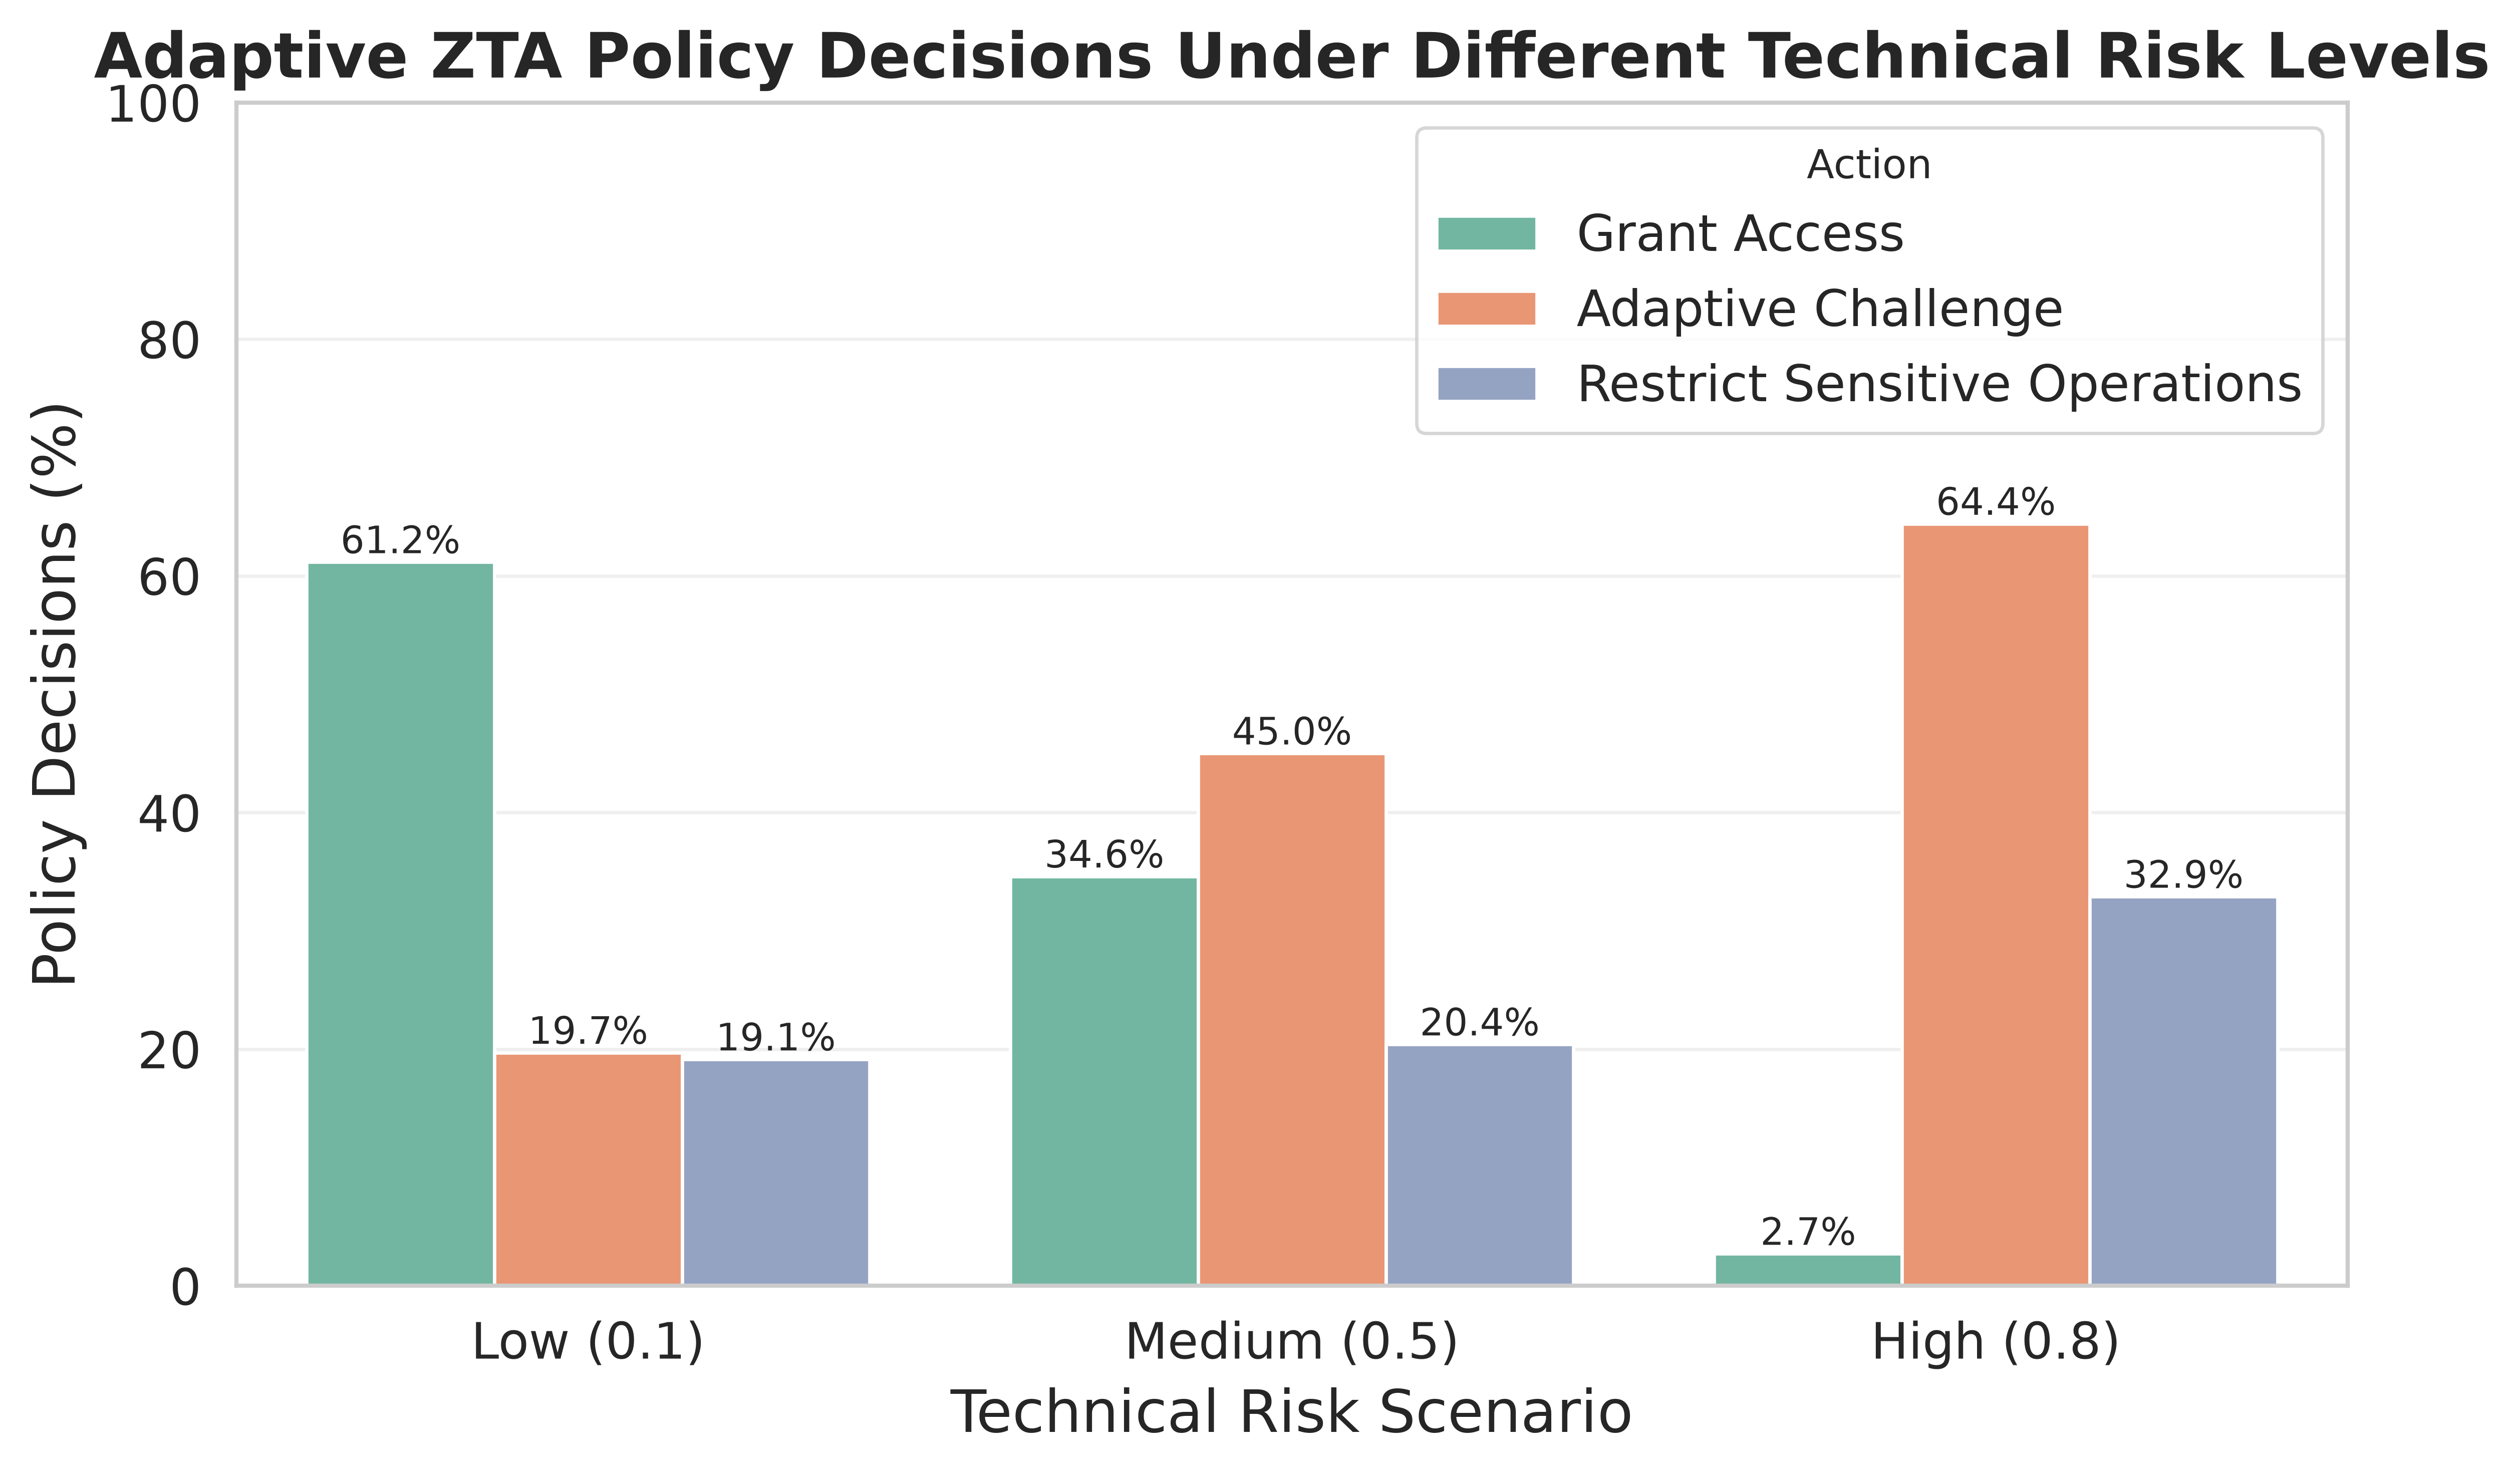

In [13]:
"""
5. ZTA POLICY ENGINE COMPARISON
Generates a bar plot to visualize the distribution of ZTA policy decisions under different technical risk levels.
"""

technical_levels = {
    "Low (0.1)":0.1,
    "Medium (0.5)":0.5,
    "High (0.8)":0.8
}

results=[]

for level,tech in technical_levels.items():

    actions=[]

    for p in y_probs:

        action,_ = zta_policy_decision_engine(
            technical_risk_score=tech,
            human_risk_probability=p
        )

        actions.append(action)

    counts = pd.Series(actions).value_counts()

    percentages = counts / counts.sum() * 100

    for action, percent in percentages.items():

        results.append({

            "Scenario":level,
            "Action":action,
            "Percentage":percent

        })

zta_df = pd.DataFrame(results)

plt.figure(figsize=(8,5))

zta_df["Action"] = zta_df["Action"].replace({
    "GRANT_ACCESS": "Grant Access",
    "ADAPTIVE_CHALLENGE": "Adaptive Challenge",
    "RESTRICT_SENSITIVE_OPS": "Restrict Sensitive Operations"
})

zta_df["Action"] = pd.Categorical(
    zta_df["Action"],
    categories=[
        "Grant Access",
        "Adaptive Challenge",
        "Restrict Sensitive Operations"
    ],
    ordered=True
)

ax = sns.barplot(

    data=zta_df,

    x="Scenario",

    y="Percentage",

    hue="Action",

    palette="Set2"

)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=9
    )

plt.title(

    "Adaptive ZTA Policy Decisions Under Different Technical Risk Levels",

    fontsize=15,

    weight="bold"

)

plt.ylabel("Policy Decisions (%)")

plt.ylim(0,100)

plt.grid(
    axis="y",
    alpha=0.3
)
plt.xlabel("Technical Risk Scenario")

plt.tight_layout()

plt.savefig(

    f"{output_dir}/5_zta_policy_distribution.png",

    dpi=600,

    bbox_inches="tight"

)

plt.savefig(
    f"{output_dir}/5_zta_policy_distribution.pdf",
    bbox_inches="tight"
)